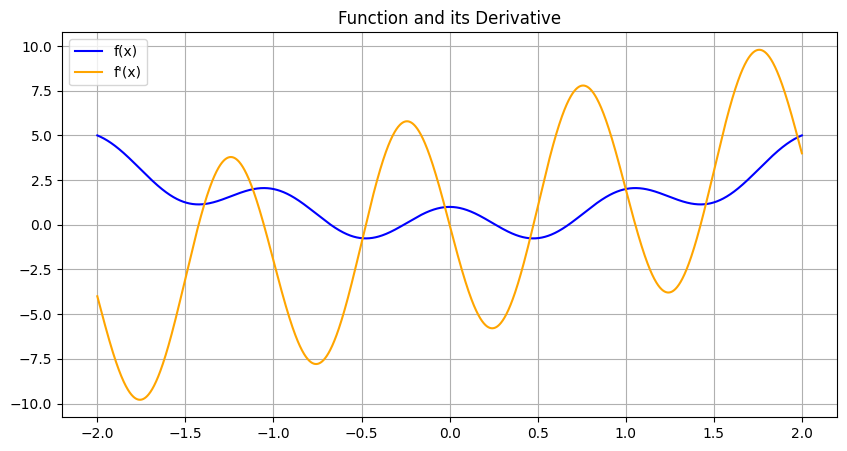

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
# make the equations look nicer
from IPython.display import display


# plot fx and dx
x = np.linspace(-2, 2, 2001)
def f(x):
    return np.cos(2 * np.pi * x) + x**2
def df(x):
    return -2 * np.pi * np.sin(2 * np.pi * x) + 2 * x

plt.figure(figsize=(10, 5))
plt.plot(x, f(x), label='f(x)', color='blue')
plt.plot(x, df(x), label="f'(x)", color='orange')
plt.title('Function and its Derivative')
plt.legend()
plt.grid()
plt.show()


[1.25]


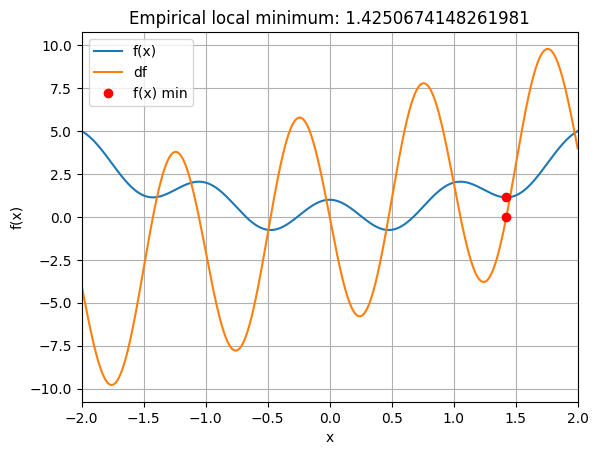

In [112]:
# random starting point
localmin = np.random.choice(x,1)
# localmin = np.zeros(1)
print(localmin)

# learning parameters
learning_rate = .01
training_epochs = 100

# run through training , this implements the gradient descent algorithm
for i in range(training_epochs):
  grad = df(localmin)
  localmin = localmin - learning_rate*grad

localmin
# plot the results

plt.plot(x,f(x), x,df(x))
plt.plot(localmin,df(localmin),'ro')
plt.plot(localmin,f(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Empirical local minimum: %s'%localmin[0])
plt.show()


start point is : [1.952]
210
Local min [1.42506741]


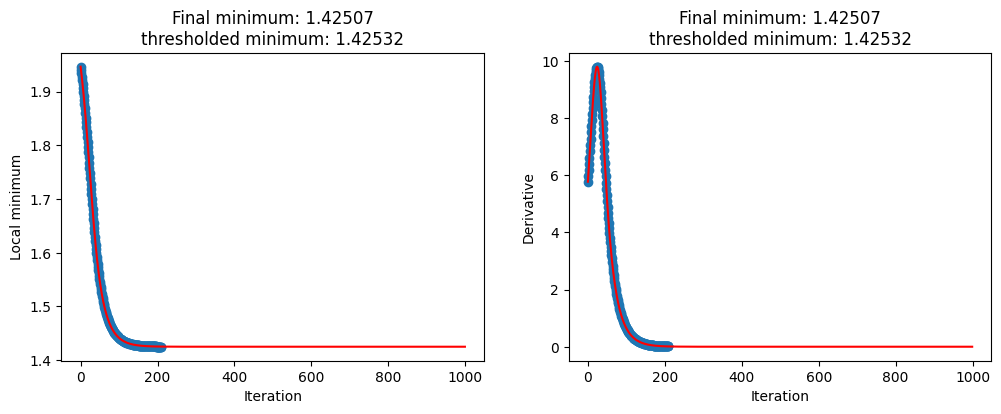

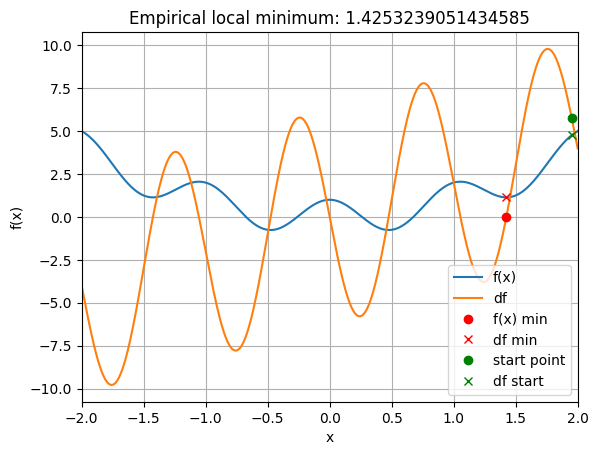

In [277]:
# random starting point
start = np.random.choice(x,1)
# localmin = np.array([0]) # leads to a vanishing gradient scenario...
print("start point is :",start)
localmin = start

# learning parameters
learning_rate = 0.001 # if learnning rate is small more training epoch is needed.
training_epochs = 1000
threshold = 0.01

# run through training and store all the results
thflg = 0
modelparams = np.zeros((training_epochs,2))
for i in range(training_epochs):
  grad = df(localmin)
  localmin = localmin - learning_rate*grad
  modelparams[i,0] = localmin[0] # localmin[0] is used inplace of localmin because localmin is an array of size 1
  modelparams[i,1] = grad[0]
  if np.abs(grad) < threshold: # stopping criterion based
    if not(thflg):
      thd_epochs = i+1
      thd_localmin = localmin
      thflg = 1

  # plot the gradient over iterations
print(thd_epochs)
print("Local min",localmin)
thd_modelparams = modelparams[:thd_epochs]

fig,ax = plt.subplots(1,2,figsize=(12,4))

for i in range(2):
  ax[i].plot(thd_modelparams[:,i],'o-') # the significance of ',' in thd_modelparams[:,i] is that it separates the row index from the column index
  ax[i].plot(modelparams[:,i],'r-')
  ax[i].set_xlabel('Iteration')
  ax[i].set_title(f'Final minimum: {localmin[0]:.5f}\nthresholded minimum: {thd_localmin[0]:.5f}')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')

plt.show()

plt.plot(x,f(x), x,df(x))
plt.plot(thd_localmin[0],df(thd_localmin[0]),'ro')
plt.plot(thd_localmin[0],f(thd_localmin[0]),'rx')
plt.plot(start[0],df(start[0]),'go')
plt.plot(start[0],f(start[0]),'gx')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min','df min','start point','df start'])
plt.title('Empirical local minimum: %s'%thd_localmin[0])
plt.show()


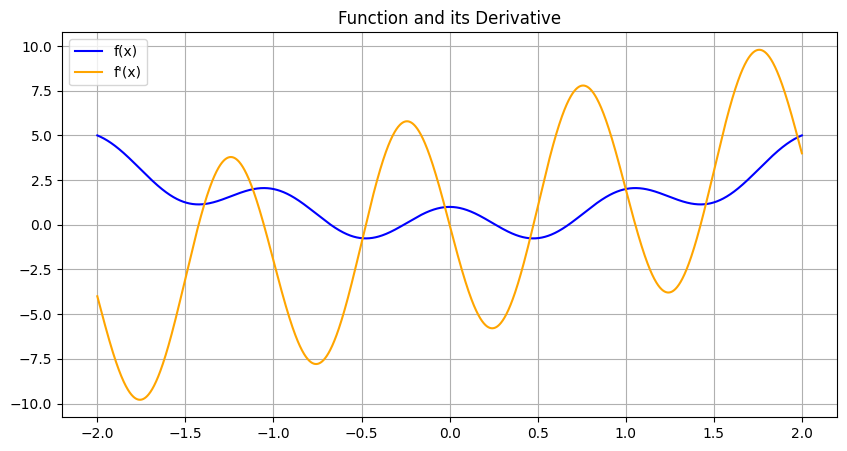

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
# make the equations look nicer
from IPython.display import display


# x_vals = np.linspace(-2, 2, 400)
# fx_vals = [sym.lambdify(x, fx)(val) for val in x_vals]
# dx_vals = [sym.lambdify(x, dx)(val) for val in x_vals]

def fx():
    # create symbolic variables in sympy
    x = sym.symbols('x')
    # define the function f(x) = cos(2pix)+x**2
    return sym.cos(2 * np.pi * x) + x**2


# define a function that computes the value of f(x) based on the function fx for the input x
def f(i):
    x = sym.symbols('x')
    return sym.lambdify(x, fx(), modules='numpy')(i)

def dfx():
    # create symbolic variables in sympy
    x = sym.symbols('x')
    # define the function f'(x)
    return sym.diff(fx(), x)  # compute the derivative of f(x) with respect to x

def df(i):
    x = sym.symbols('x')
    return sym.lambdify(x, dfx(), modules='numpy')(i)

# display(fx(),dfx())


x = np.linspace(-2, 2, 2001)
plt.figure(figsize=(10, 5))
plt.plot(x, f(x), label='f(x)', color='blue')
plt.plot(x, df(x), label="f'(x)", color='orange')
plt.title('Function and its Derivative')
plt.legend()
plt.grid()
plt.show()